# Chapter 5 — LLM evaluation report

This notebook reproduces the **Chapter 5** thesis figures and tables for evaluating the drought-impact extraction framework.

## What we are doing

To evaluate extraction quality, a **manually annotated event-level evaluation dataset** was built. Articles describe realised drought impacts in the Netherlands, so the evaluation focuses on whether models extract the right events (location, impact category, severity, recency), not on discovering impacts from scratch in an open corpus.

Every gold event is a reported **location** together with its **impact category**, **severity**, **temporal recency**, and supporting evidence. Model predictions are compared against these annotations.

**Pipeline (how this package was produced):**

1. **Annotate** — Streamlit labeller (`src/label_dataset.py`) → `data/evaluation_set.json`
2. **Run LLMs** — same prompt/schema for five models (`src/run_models.py`; needs private corpus + API keys)
3. **Score** — offline event-tuple matching → stored in `data/model_metrics.json`
4. **Post-hoc review** — manual TP/FP on a subset → `data/posthoc.json`; `src/restrict_posthoc.py` filters to the nine shared articles → `data/posthoc_restricted.json`
5. **This notebook** — loads the frozen JSON files, shows the calculations, and writes `results/`

## File provenance

| File | Loaded from | Originally generated by |
|------|-------------|-------------------------|
| `data/evaluation_set.json` | this package (`CHAPTER/data/`) | Manual annotation via `src/label_dataset.py` |
| `data/model_metrics.json` | this package | Offline tuple matching of LLM outputs vs gold (P/R/F1 stored here; full article/LLM dumps are **not** shipped) |
| `data/posthoc.json` | this package | Full manual post-hoc archive (impact labels + attribute labels) |
| `data/posthoc_restricted.json` | this package | Nine shared articles only; written by `src/restrict_posthoc.py` / this notebook |
| `results/figures/*`, `results/tables/*` | **written by this notebook** | Regenerated whenever you run all cells |

Newspaper article bodies are omitted on purpose (LexisNexis / copyright).

## 1. Setup — load data

The next cell resolves the chapter root (`CHAPTER`) whether you open the notebook from `chapter_05/` or from `chapter_05/notebooks/`.

- **Inputs** are read from `CHAPTER/data/` (the three frozen JSON files above).
- **Outputs** are written to `CHAPTER/results/figures/` and `CHAPTER/results/tables/` for use in Overleaf / the thesis PDF.

No API keys are required for this notebook: it only analyses already-frozen annotations and metrics.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

_cwd = Path.cwd().resolve()
CHAPTER = _cwd.parent if (_cwd.parent / "data" / "evaluation_set.json").exists() else _cwd
DATA = CHAPTER / "data"
RESULTS_FIG = CHAPTER / "results" / "figures"
RESULTS_TAB = CHAPTER / "results" / "tables"
RESULTS_FIG.mkdir(parents=True, exist_ok=True)
RESULTS_TAB.mkdir(parents=True, exist_ok=True)

evaluation = json.loads((DATA / "evaluation_set.json").read_text(encoding="utf-8"))
metrics = json.loads((DATA / "model_metrics.json").read_text(encoding="utf-8"))
posthoc = json.loads((DATA / "posthoc.json").read_text(encoding="utf-8"))

src = CHAPTER / "src"
if str(src) not in sys.path:
    sys.path.insert(0, str(src))
import restrict_posthoc

restricted_payload, posthoc_precision_rows, posthoc_attr_raw_rows, posthoc_attr_rows = (
    restrict_posthoc.build_restricted_payload(posthoc)
)
restrict_posthoc.save_json(DATA / "posthoc_restricted.json", restricted_payload)

reviews_df = pd.DataFrame(evaluation.get("article_reviews") or [])
events_df = pd.DataFrame(evaluation.get("event_records") or [])

print(f"CHAPTER = {CHAPTER}")
print(f"reviews = {len(reviews_df)}, events = {len(events_df)}, model runs = {metrics.get('run_count')}")
print(
    f"post-hoc restriction: {restricted_payload['restriction']['n_kept']} shared articles "
    f"(full archive remains in posthoc.json)"
)

CHAPTER = C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\05_llm_evaluation
reviews = 65, events = 33, model runs = 5
post-hoc restriction: 9 shared articles (full archive remains in posthoc.json)


## 2. Evaluation dataset (thesis § Final Evaluation Dataset)

### Purpose and construction

The evaluation set was built with an **iterative sampling** procedure to maximise coverage of drought impact types rather than mirror the true frequency of impacts in Dutch news. Articles were reviewed and annotated until at least **ten** of the twenty predefined impact categories were covered.

Annotations were made with a custom Streamlit app (`src/label_dataset.py`): each relevant article can contribute one or more events. An event is a location plus impact category, severity, temporal recency, and evidence.

### What the frozen file contains

**Loaded from:** `data/evaluation_set.json`  
**Fields used here:** `article_reviews` (relevance labels) and `event_records` (the gold events).

Expected thesis size:

- **65** reviewed newspaper articles  
- **33** manually annotated drought-impact events  
- **10** distinct impact categories (of 20 in the taxonomy)

### How we count (shown in the next cells)

- reviewed articles = `len(article_reviews)`
- events = `len(event_records)`
- impact-class coverage = number of distinct `impact_class` values among events
- label breakdown = value counts of `Relevant` / `Irrelevant` / `Uncertain`

### Figures

Bar charts of **severity**, **recency**, and **impact category** match the thesis distribution figure. Most annotated impacts are low/moderate severity and recent (within about a month of publication), reflecting news reporting. The impact distribution is uneven (agriculture, water, ecosystems, forest-related impacts dominate). One article that lists the same impact at many locations can skew a category — that is expected under the event definition (one event per location).

**This notebook writes:** `results/tables/dataset_summary.csv` and `results/figures/{severity,recency,impact_class}_distribution.png`.

In [2]:
n_reviews = len(reviews_df)
n_events = len(events_df)
n_impact_classes = int(events_df["impact_class"].nunique())
label_counts = reviews_df["label"].value_counts() if "label" in reviews_df.columns else pd.Series(dtype=int)

dataset_summary = pd.DataFrame(
    [
        {"metric": "reviewed_articles", "value": n_reviews},
        {"metric": "extracted_events", "value": n_events},
        {"metric": "distinct_impact_classes", "value": n_impact_classes},
        *[{"metric": f"label_{lab}", "value": int(cnt)} for lab, cnt in label_counts.items()],
    ]
)
display(dataset_summary)
dataset_summary.to_csv(RESULTS_TAB / "dataset_summary.csv", index=False)
print(f"Wrote {RESULTS_TAB / 'dataset_summary.csv'}")

print("\nLabel counts:")
display(label_counts.to_frame("count"))

print("Impact class counts among the 33 events:")
display(events_df["impact_class"].value_counts().to_frame("count"))

,metric,value
0,reviewed_articles,65
1,extracted_events,33
2,distinct_impact_classes,10
3,label_Irrelevant,41
4,label_Uncertain,13
5,label_Relevant,11


Wrote C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\05_llm_evaluation\results\tables\dataset_summary.csv

Label counts:


,count
label,
Irrelevant,41
Uncertain,13
Relevant,11


Impact class counts among the 33 events:


,count
impact_class,
Freshwater Ecosystem Degradation,8
Crop Failure & Yield Reduction,6
Water Supply & Sanitation Issues,5
Forest Dieback & Vegetation Stress,5
Agricultural Economic Loss,3
Wildfire Occurrence,2
Reservoir & Surface Water Shortage,1
Water Use Restrictions,1
Heat & Air Quality Health Impacts,1


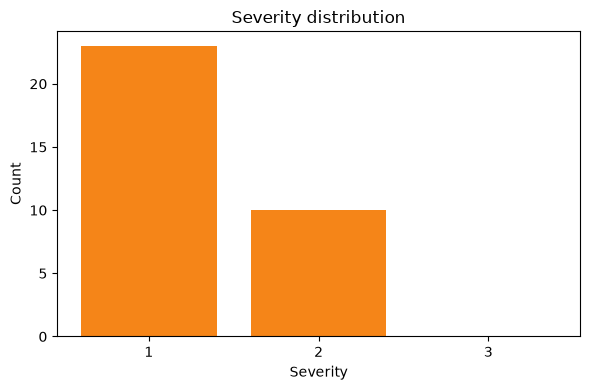

Wrote C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\05_llm_evaluation\results\figures\severity_distribution.png


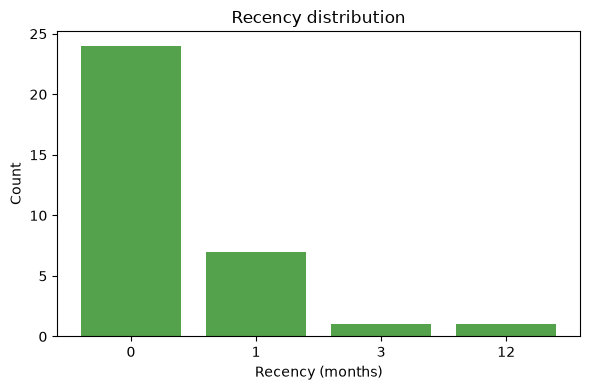

Wrote C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\05_llm_evaluation\results\figures\recency_distribution.png


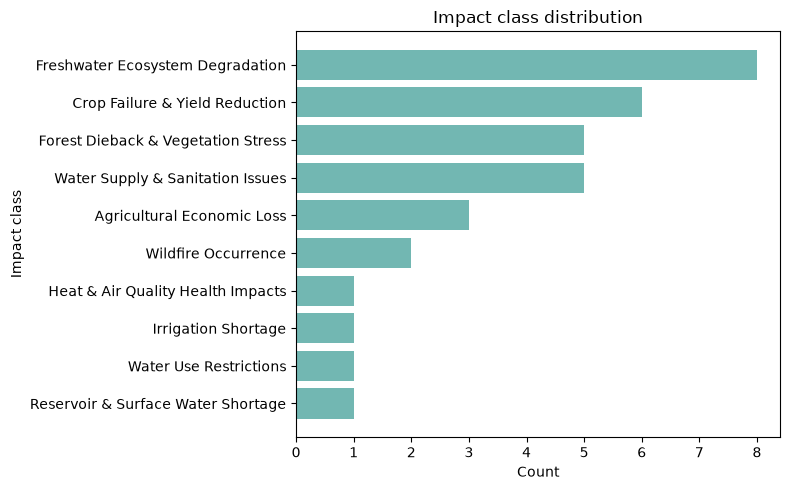

Wrote C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\05_llm_evaluation\results\figures\impact_class_distribution.png


In [3]:
def bar_counts(series: pd.Series, title: str, xlabel: str, ylabel: str, color: str, path: Path, horizontal: bool = False):
    ordered = series.sort_values(ascending=True) if horizontal else series
    fig, ax = plt.subplots(figsize=(8, 5) if horizontal else (6, 4))
    if horizontal:
        ax.barh(ordered.index.astype(str), ordered.values, color=color)
    else:
        ax.bar(ordered.index.astype(str), ordered.values, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Wrote {path}")

sev = (
    pd.to_numeric(events_df["severity"], errors="coerce")
    .value_counts()
    .reindex([1, 2, 3], fill_value=0)
    .astype(int)
)
rec = (
    pd.to_numeric(events_df["recency"], errors="coerce")
    .value_counts()
    .sort_index()
    .astype(int)
)
imp = events_df["impact_class"].astype(str).value_counts()

bar_counts(sev, "Severity distribution", "Severity", "Count", "#F58518", RESULTS_FIG / "severity_distribution.png")
bar_counts(rec, "Recency distribution", "Recency (months)", "Count", "#54A24B", RESULTS_FIG / "recency_distribution.png")
bar_counts(
    imp,
    "Impact class distribution",
    "Count",
    "Impact class",
    "#72B7B2",
    RESULTS_FIG / "impact_class_distribution.png",
    horizontal=True,
)

## 3. Event-level model performance

### Evaluated models (controlled setup)

Five commercial LLMs were run under **identical** conditions: same newspaper articles (Relevant + Irrelevant from the evaluation set), same system prompt, same Pydantic extraction schema, temperature **0**, structured-output validation with retries, LiteLLM as the common API layer. No model-specific prompt tuning.

| Provider | Model (thesis naming) |
|----------|------------------------|
| Google | Gemini 3.5 Flash, Gemini 3.1 Pro, Gemini 3.1 Flash-Lite |
| Anthropic | Claude Sonnet 4.5 |
| OpenAI | GPT-5.4 mini |

The goal is not “which vendor is best in general”, but which model balances extraction quality and cost for building a large drought-impact database from ~20k news articles. Inference prices used in the thesis are listed in the cost table cell below (May 2026).

### Formulas

$$
Precision = \frac{TP}{TP + FP},\qquad
Recall = \frac{TP}{TP + FN},\qquad
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

### Matching rules

- **Location + Impact** (primary): a prediction counts as TP only if `(location, impact_class)` matches a gold event exactly after normalisation. Events are matched as unordered multisets (order inside an article does not matter).
- **Location + Impact + Severity + Recency** (stricter): the full 4-tuple must match. Performance drops for every model under this rule, because attribute errors count as misses.

### Where the numbers come from

**Loaded from:** `data/model_metrics.json` → `run_summaries` (one row per model run).

TP/FP/FN were computed **offline** by comparing each model’s LLM outputs to the gold events in `evaluation_set.json`. This package ships only the resulting scores (`location_impact_*`, `location_impact_severity_recency_*`) plus `reference_event_count` / `predicted_event_count`. Full selected-article and LLM-output JSON dumps are omitted (copyright).

This notebook therefore:

1. displays the stored (unrounded) metrics,  
2. rounds them to three decimals for the thesis table,  
3. checks that stored F1 equals \(2PR/(P+R)\) from the stored P and R.

**Written by this notebook:** `results/tables/model_performance.csv`, `results/tables/model_costs.csv`.

In [4]:
DISPLAY_NAMES = {
    "gemini_gemini-3.5-flash": "Gemini 3.5 Flash",
    "gemini_gemini-3.1-pro-preview": "Gemini 3.1 Pro",
    "anthropic_claude-sonnet-4-5": "Claude Sonnet 4.5",
    "gemini_gemini-3.1-flash-lite": "Gemini 3.1 Flash-Lite",
    "gpt-5.4-mini": "GPT-5.4 mini",
}

by_model = {row["model"]: row for row in metrics["run_summaries"]}

detail_rows = []
perf_rows = []
for model_id, name in DISPLAY_NAMES.items():
    r = by_model[model_id]
    detail_rows.append(
        {
            "model": name,
            "reference_events": r["reference_event_count"],
            "predicted_events": r["predicted_event_count"],
            "loc+impact P": r["location_impact_precision"],
            "loc+impact R": r["location_impact_recall"],
            "loc+impact F1": r["location_impact_f1"],
            "full-tuple P": r["location_impact_severity_recency_precision"],
            "full-tuple R": r["location_impact_severity_recency_recall"],
            "full-tuple F1": r["location_impact_severity_recency_f1"],
        }
    )
    perf_rows.append(
        {
            "model": name,
            "model_id": model_id,
            "location_impact_precision": round(r["location_impact_precision"], 3),
            "location_impact_recall": round(r["location_impact_recall"], 3),
            "location_impact_f1": round(r["location_impact_f1"], 3),
            "location_impact_severity_recency_precision": round(r["location_impact_severity_recency_precision"], 3),
            "location_impact_severity_recency_recall": round(r["location_impact_severity_recency_recall"], 3),
            "location_impact_severity_recency_f1": round(r["location_impact_severity_recency_f1"], 3),
        }
    )

detail_df = pd.DataFrame(detail_rows)
perf_df = pd.DataFrame(perf_rows)

print("Unrounded metrics + event counts (from model_metrics.json)")
display(detail_df.style.format(
    {
        "loc+impact P": "{:.4f}",
        "loc+impact R": "{:.4f}",
        "loc+impact F1": "{:.4f}",
        "full-tuple P": "{:.4f}",
        "full-tuple R": "{:.4f}",
        "full-tuple F1": "{:.4f}",
    }
))

print("Thesis table (rounded to 3 decimals)")
display(perf_df)
perf_df.to_csv(RESULTS_TAB / "model_performance.csv", index=False)
print(f"Wrote {RESULTS_TAB / 'model_performance.csv'}")

# Sanity: F1 should equal 2PR/(P+R) for the stored P and R
print("\nCheck: recompute F1 from stored P and R (should match stored F1 within rounding)")
checks = []
for _, row in detail_df.iterrows():
    for prefix, p_col, r_col, f_col in [
        ("loc+impact", "loc+impact P", "loc+impact R", "loc+impact F1"),
        ("full-tuple", "full-tuple P", "full-tuple R", "full-tuple F1"),
    ]:
        p, r, f = row[p_col], row[r_col], row[f_col]
        f_re = (2 * p * r / (p + r)) if (p + r) else float("nan")
        checks.append({"model": row["model"], "metric": prefix, "F1_stored": f, "F1_from_PR": f_re, "abs_diff": abs(f - f_re)})
display(pd.DataFrame(checks))

Unrounded metrics + event counts (from model_metrics.json)


,model,reference_events,predicted_events,loc+impact P,loc+impact R,loc+impact F1,full-tuple P,full-tuple R,full-tuple F1
0,Gemini 3.5 Flash,33,32,0.4688,0.4545,0.4615,0.1875,0.1818,0.1846
1,Gemini 3.1 Pro,33,34,0.2059,0.2121,0.2090,0.1176,0.1212,0.1194
2,Claude Sonnet 4.5,33,47,0.1915,0.2727,0.2250,0.0638,0.0909,0.0750
3,Gemini 3.1 Flash-Lite,33,33,0.2424,0.2424,0.2424,0.0606,0.0606,0.0606
4,GPT-5.4 mini,33,51,0.1569,0.2424,0.1905,0.0196,0.0303,0.0238


Thesis table (rounded to 3 decimals)


,model,model_id,location_impact_precision,location_impact_recall,location_impact_f1,location_impact_severity_recency_precision,location_impact_severity_recency_recall,location_impact_severity_recency_f1
0,Gemini 3.5 Flash,gemini_gemini-3.5-flash,0.469,0.455,0.462,0.188,0.182,0.185
1,Gemini 3.1 Pro,gemini_gemini-3.1-pro-preview,0.206,0.212,0.209,0.118,0.121,0.119
2,Claude Sonnet 4.5,anthropic_claude-sonnet-4-5,0.191,0.273,0.225,0.064,0.091,0.075
3,Gemini 3.1 Flash-Lite,gemini_gemini-3.1-flash-lite,0.242,0.242,0.242,0.061,0.061,0.061
4,GPT-5.4 mini,gpt-5.4-mini,0.157,0.242,0.190,0.020,0.030,0.024


Wrote C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\05_llm_evaluation\results\tables\model_performance.csv

Check: recompute F1 from stored P and R (should match stored F1 within rounding)


,model,metric,F1_stored,F1_from_PR,abs_diff
0,Gemini 3.5 Flash,loc+impact,0.461538,0.461538,0.0
1,Gemini 3.5 Flash,full-tuple,0.184615,0.184615,0.0
2,Gemini 3.1 Pro,loc+impact,0.208955,0.208955,0.0
3,Gemini 3.1 Pro,full-tuple,0.119403,0.119403,0.0
4,Claude Sonnet 4.5,loc+impact,0.225000,0.225000,0.0
5,Claude Sonnet 4.5,full-tuple,0.075000,0.075000,0.0
6,Gemini 3.1 Flash-Lite,loc+impact,0.242424,0.242424,0.0
7,Gemini 3.1 Flash-Lite,full-tuple,0.060606,0.060606,0.0
8,GPT-5.4 mini,loc+impact,0.190476,0.190476,0.0
9,GPT-5.4 mini,full-tuple,0.023810,0.023810,0.0


In [5]:
# Manual cost table from the thesis (May 2026 pricing) — not computed from code
costs_df = pd.DataFrame(
    [
        {"provider": "Anthropic", "model": "Claude 4.6 Sonnet", "input_per_1M_usd": 3.00, "output_per_1M_usd": 15.00},
        {"provider": "OpenAI", "model": "GPT-5.4 mini", "input_per_1M_usd": 0.75, "output_per_1M_usd": 4.50},
        {"provider": "Google", "model": "Gemini 3.1 Pro", "input_per_1M_usd": 2.00, "output_per_1M_usd": 12.00},
        {"provider": "Google", "model": "Gemini 3.5 Flash", "input_per_1M_usd": 1.50, "output_per_1M_usd": 9.00},
        {"provider": "Google", "model": "Gemini 3.1 Flash-Lite", "input_per_1M_usd": 0.25, "output_per_1M_usd": 1.50},
    ]
)
display(costs_df)
costs_df.to_csv(RESULTS_TAB / "model_costs.csv", index=False)
print(f"Wrote {RESULTS_TAB / 'model_costs.csv'}")

,provider,model,input_per_1M_usd,output_per_1M_usd
0,Anthropic,Claude 4.6 Sonnet,3.00,15.0
1,OpenAI,GPT-5.4 mini,0.75,4.5
2,Google,Gemini 3.1 Pro,2.00,12.0
3,Google,Gemini 3.5 Flash,1.50,9.0
4,Google,Gemini 3.1 Flash-Lite,0.25,1.5


Wrote C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\05_llm_evaluation\results\tables\model_costs.csv


## 4. Post-hoc impact precision

### Why a post-hoc step?

Strict event-level matching can **underestimate** extraction quality when impact categories overlap (fuzzy boundaries). For example, reduced water for irrigation might reasonably be labelled as irrigation shortage, water-use restrictions, or reservoir shortage. Annotation forces a single gold category, so a semantically sensible model prediction can still be scored wrong.

The post-hoc review therefore inspects model extractions **impacts** on **nine articles that appear in both** the impact-validity pass and the attribute pass, and marks each extraction as valid (TP) or incorrect (FP), reducing the effect of exact category mismatch. Extractions whose location is only “the Netherlands” were treated as too coarse for regional analysis and excluded from this check where applicable. Two extra rows in the full archive are dropped so both post-hoc tables use the same sample: `NEWS_2018_011316` (Irrelevant lagoon edge case) and `NEWS_2020_018637` (attribute review only).

### Calculation (fully visible in the next cell)

**Loaded from:** `data/posthoc.json` filtered by `src/restrict_posthoc.py` to the nine shared article IDs (`data/posthoc_restricted.json`).
Each row has `model_name`, `article_id`, `tp_count`, `fp_count` from manual review.

For each model:

$$
TP = \sum tp\_count,\qquad
FP = \sum fp\_count,\qquad
Precision = \frac{TP}{TP + FP}
$$

**Written by this notebook:** `results/tables/posthoc_impact_precision.csv` (thesis Table of post-hoc results).

In [6]:
entries = restricted_payload["impact_labels"]["review_entries"]
print(f"Post-hoc review rows (9 shared articles): {len(entries)}")
print("Kept:", ", ".join(restricted_payload["restriction"]["kept_article_ids"]))

sample = pd.DataFrame(entries)[["model_name", "article_id", "tp_count", "fp_count"]].head(8)
display(sample)

posthoc_df = pd.DataFrame(posthoc_precision_rows)
display(posthoc_df)
restrict_posthoc.write_csv(
    RESULTS_TAB / "posthoc_impact_precision.csv",
    posthoc_precision_rows,
    ["model", "model_id", "TP", "FP", "precision"],
)
print(f"Wrote {RESULTS_TAB / 'posthoc_impact_precision.csv'}")

Post-hoc review rows (9 shared articles): 45
Kept: NEWS_2003_022690, NEWS_2006_024445, NEWS_2015_007768, NEWS_2017_009248, NEWS_2018_010479, NEWS_2018_010689, NEWS_2018_010835, NEWS_2019_013729, NEWS_2020_016427


,model_name,article_id,tp_count,fp_count
0,anthropic_claude-sonnet-4-5,NEWS_2003_022690,4,0
1,gemini_gemini-3.1-flash-lite,NEWS_2003_022690,2,0
2,gemini_gemini-3.1-pro-preview,NEWS_2003_022690,3,1
3,gemini_gemini-3.5-flash,NEWS_2003_022690,6,0
4,gpt-5.4-mini,NEWS_2003_022690,2,2
5,anthropic_claude-sonnet-4-5,NEWS_2006_024445,3,0
6,gemini_gemini-3.1-flash-lite,NEWS_2006_024445,1,1
7,gemini_gemini-3.1-pro-preview,NEWS_2006_024445,2,0


,model,model_id,TP,FP,precision
0,Claude Sonnet 4.5,anthropic_claude-sonnet-4-5,26,0,1.000
1,Gemini 3.5 Flash,gemini_gemini-3.5-flash,26,0,1.000
2,Gemini 3.1 Flash Lite,gemini_gemini-3.1-flash-lite,16,2,0.889
3,Gemini 3.1 Pro Preview,gemini_gemini-3.1-pro-preview,18,3,0.857
4,GPT-5.4 Mini,gpt-5.4-mini,27,11,0.711


Wrote C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\05_llm_evaluation\results\tables\posthoc_impact_precision.csv


## 5. Location, severity, and recency extraction

After ranking models on event-level and post-hoc impact precision, a secondary check compared the two strongest models (Gemini 3.5 Flash and Claude Sonnet 4.5) on **individual attributes**:

- **Location** — spatial resolution (e.g. detailed place names vs coarse labels such as “the Netherlands”)
- **Severity** — ordinal impact severity
- **Recency** — temporal bucket relative to publication

### Raw vs reconstructed usable-location table

**Loaded from:** `data/posthoc.json` → `attribute_labels.review_entries`, restricted to the same nine articles.

Raw TP/FN totals are summed from the per-article attribute UI rows.

The **usable-location** column reconstructs the published spatial-usability filter by subtracting potato-article (`NEWS_2020_018637`) `location_tp` from the published thesis usable counts. Place names were **not** re-filtered. Severity and recency come from the nine-article JSON sums.

**Written by this notebook:**

- `results/tables/posthoc_attributes_raw.csv` — nine-article JSON sums  
- `results/tables/posthoc_attributes.csv` — reconstructed usable locations + nine-article severity/recency

In [7]:
raw_df = pd.DataFrame(posthoc_attr_raw_rows)
print("Raw attribute counts on the nine shared articles")
display(raw_df)
restrict_posthoc.write_csv(
    RESULTS_TAB / "posthoc_attributes_raw.csv",
    posthoc_attr_raw_rows,
    [
        "model_id",
        "loc_tp_raw",
        "loc_fn_raw",
        "loc_count_raw",
        "sev_tp_raw",
        "sev_fn_raw",
        "rec_tp_raw",
        "rec_fn_raw",
        "note",
    ],
)

thesis_attr = pd.DataFrame(posthoc_attr_rows)
print("Reconstructed usable-location table (potato article subtracted from published usable loc TP)")
display(thesis_attr)
restrict_posthoc.write_csv(
    RESULTS_TAB / "posthoc_attributes.csv",
    posthoc_attr_rows,
    ["model", "loc_tp", "loc_fn", "sev_tp", "sev_fn", "rec_tp", "rec_fn", "source"],
)
print(f"Wrote {RESULTS_TAB / 'posthoc_attributes.csv'}")

Raw attribute counts on the nine shared articles


,model_id,loc_tp_raw,loc_fn_raw,loc_count_raw,sev_tp_raw,sev_fn_raw,rec_tp_raw,rec_fn_raw,note
0,gemini_gemini-3.5-flash,13,0,16,21,0,11,0,raw_json_nine_shared_articles
1,anthropic_claude-sonnet-4-5,13,0,15,21,5,11,0,raw_json_nine_shared_articles


Reconstructed usable-location table (potato article subtracted from published usable loc TP)


,model,loc_tp,loc_fn,sev_tp,sev_fn,rec_tp,rec_fn,source
0,Gemini 3.5 Flash,14,5,21,0,11,0,reconstructed_usable_location_minus_potato; se...
1,Claude Sonnet 4.5,10,5,21,5,11,0,reconstructed_usable_location_minus_potato; se...


Wrote C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\05_llm_evaluation\results\tables\posthoc_attributes.csv


## Done

All Chapter 5 thesis tables and distribution figures are displayed above and written under `results/`.

**Model selection (thesis):** based on combined event-level, post-hoc, and attribute evidence, **Gemini 3.5 Flash** was selected as the production extractor: strong extraction performance with substantially lower inference cost than the flagship Claude/Pro options, and more detailed spatial outputs in the attribute check.

**Not generated here:** fuzzy-set concept illustrations (coarse vs fine impact categorisation) live only in the Overleaf thesis (`figures/Fuzzyset*.jpg`). See the Chapter 05 README thesis-mapping note.

**To re-run models** (optional, not required for this report): `python src/run_models.py --model "..."`, which needs the private news corpus, Chapter 4 schema (`LLM proccesing/main.py`), and API keys. New dumps go under `data/runs/` (gitignored).